# BRCA Subtype Classification with GNN
## Master Thesis — BioGNN pipeline

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

from src.data_loader import build_graph_dataset
from src.model import BioGNN

c:\Users\danie\Desktop\Master_Thesis_GNN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. PATHS ---
CLINICAL_FILE  = 'data/brca_tcga_pan_can_atlas_2018_clinical_data.tsv'
EXPRESSION_FILE = 'data/mRNA expression z-scores relative to all samples (log RNA Seq V2 RSEM).txt'

# --- 2. LOAD & ALIGN ---
print('Loading data...')
clinical_df = pd.read_csv(CLINICAL_FILE, sep='\t', comment='#').dropna(subset=['Subtype'])
exp_df      = pd.read_csv(EXPRESSION_FILE, sep='\t')

# Find common samples (intersection)
common_samples = sorted(set(clinical_df['Sample ID']) & set(exp_df['SAMPLE_ID']))
print(f'Common patients found: {len(common_samples)}')

# Build expression matrix: genes as rows, patients as columns (sorted order)
exp_final = (
    exp_df[exp_df['SAMPLE_ID'].isin(common_samples)]
    .set_index('SAMPLE_ID')
    .drop(columns=['STUDY_ID'])
    .T                       # genes x patients
)[common_samples]            # enforce same order

# Clinical data aligned to same order
clinical_final = (
    clinical_df[clinical_df['Sample ID'].isin(common_samples)]
    .set_index('Sample ID')
    .loc[common_samples]     # same order as exp_final
)

print(f'Expression matrix shape: {exp_final.shape}  (genes x patients)')
print(f'Genes: {exp_final.index.tolist()}')
print(f'Subtype distribution:\n{clinical_final["Subtype"].value_counts()}')

Loading data...
Common patients found: 981
Expression matrix shape: (28, 981)  (genes x patients)
Genes: ['TP53AKT1', 'BCL2', 'BIRC5', 'BRCA1', 'BRCA2', 'CCNE1', 'CDH1', 'CDK4', 'CDKN2A', 'EGFR', 'ERBB2', 'ESR1', 'FGFR1', 'FOXA1', 'GATA3', 'IGF1R', 'KMT2C', 'KRAS', 'MAP3K1', 'MDM2', 'MET', 'MKI67', 'MYC', 'NF1', 'PIK3CA', 'PTEN', 'RB1', 'Unnamed: 29']
Subtype distribution:
Subtype
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64


In [3]:
# --- 3. BUILD PPI from STRING-DB ---
ppi_raw = pd.read_csv('data/string_interactions_short.tsv', sep='\t')
ppi_raw = ppi_raw.rename(columns={'#node1': 'node1'})

# Keep only high-confidence interactions (score >= 0.4 out of 1.0)
ppi_df = ppi_raw[ppi_raw['combined_score'] >= 0.4][['node1', 'node2']].reset_index(drop=True)
print(f'Real STRING-DB edges (score >= 0.4): {len(ppi_df)}')

print('Building graph objects...')
dataset, encoder = build_graph_dataset(exp_final, ppi_df, clinical_final)
print(f'Total graphs (patients): {len(dataset)}')

Real STRING-DB edges (score >= 0.4): 312
Building graph objects...
Classes: ['BRCA_Basal', 'BRCA_Her2', 'BRCA_LumA', 'BRCA_LumB', 'BRCA_Normal']
Graph edges: 518
Total graphs (patients): 981


In [4]:
# --- 4. TRAIN / TEST SPLIT ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False)

model     = BioGNN(num_node_features=1, hidden_channels=64,
                   num_classes=len(encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Class weights — inverse frequency so rare subtypes (Her2, Normal) get more attention
counts  = clinical_final['Subtype'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum() * len(counts)  # normalise
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))
print(f'Class weights: { {c: round(w, 3) for c, w in zip(encoder.classes_, weights.tolist())} }')

Using device: cpu
Class weights: {'BRCA_Basal': 0.546, 'BRCA_Her2': 1.198, 'BRCA_LumA': 0.187, 'BRCA_LumB': 0.474, 'BRCA_Normal': 2.595}


In [5]:
# --- 5. TRAINING LOOP ---
def evaluate(loader, data_list):
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out   = model(batch.x, batch.edge_index, batch.batch)
            correct += int((out.argmax(dim=1) == batch.y).sum())
    return correct / len(data_list)

history = {'loss': [], 'train_acc': [], 'test_acc': []}
print(f'Starting training on {device}...')

for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    t_acc = evaluate(train_loader, train_data)
    v_acc = evaluate(test_loader,  test_data)
    history['loss'].append(total_loss / len(train_data))
    history['train_acc'].append(t_acc)
    history['test_acc'].append(v_acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Loss: {history["loss"][-1]:.4f} | '
              f'Train Acc: {t_acc:.4f} | Test Acc: {v_acc:.4f}')

print('\nTraining complete!')
print(f'Final Test Accuracy: {history["test_acc"][-1]:.4f}')

Starting training on cpu...
Epoch 010 | Loss: 1.3360 | Train Acc: 0.5867 | Test Acc: 0.6599
Epoch 020 | Loss: 1.2666 | Train Acc: 0.5791 | Test Acc: 0.6345
Epoch 030 | Loss: 1.2501 | Train Acc: 0.6071 | Test Acc: 0.7056
Epoch 040 | Loss: 1.2468 | Train Acc: 0.5702 | Test Acc: 0.6650
Epoch 050 | Loss: 1.2295 | Train Acc: 0.5587 | Test Acc: 0.6142
Epoch 060 | Loss: 1.2318 | Train Acc: 0.5472 | Test Acc: 0.5939
Epoch 070 | Loss: 1.1932 | Train Acc: 0.5408 | Test Acc: 0.5939
Epoch 080 | Loss: 1.2005 | Train Acc: 0.5612 | Test Acc: 0.6447
Epoch 090 | Loss: 1.2163 | Train Acc: 0.5791 | Test Acc: 0.6650
Epoch 100 | Loss: 1.1757 | Train Acc: 0.5510 | Test Acc: 0.6193

Training complete!
Final Test Accuracy: 0.6193


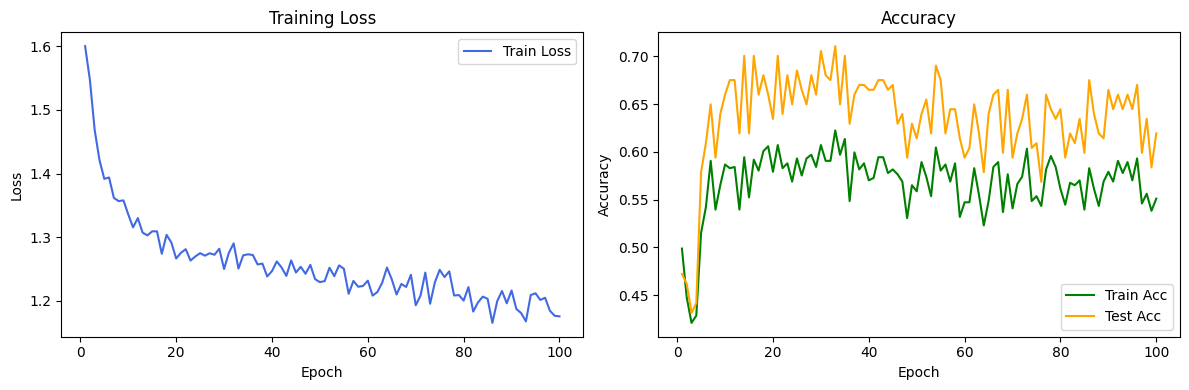

Plot saved to training_curves.png


In [6]:
# --- 6. VISUALISE TRAINING CURVES ---
epochs = range(1, len(history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['loss'], label='Train Loss', color='royalblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend()

ax2.plot(epochs, history['train_acc'], label='Train Acc', color='green')
ax2.plot(epochs, history['test_acc'],  label='Test Acc',  color='orange')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Plot saved to training_curves.png')

In [7]:
# --- 7. PER-CLASS REPORT ---
from sklearn.metrics import classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

  BRCA_Basal       0.69      0.73      0.71        37
   BRCA_Her2       0.37      0.61      0.46        18
   BRCA_LumA       0.86      0.66      0.75       100
   BRCA_LumB       0.59      0.44      0.50        39
 BRCA_Normal       0.05      0.33      0.08         3

    accuracy                           0.62       197
   macro avg       0.51      0.55      0.50       197
weighted avg       0.72      0.62      0.65       197



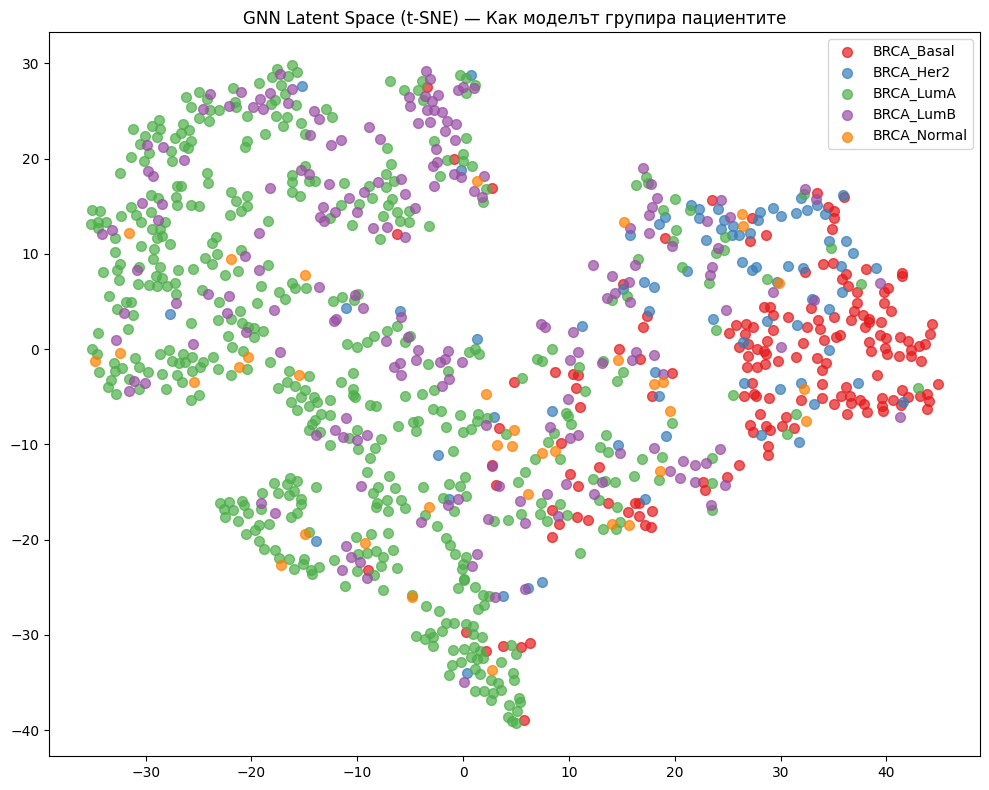

✅ Успешно запазено: gnn_latent_space.png


In [10]:
# -- 8b. t-SNE visualisation --
# Премахваме n_iter, за да избегнем грешката с версиите
tsne = TSNE(n_components=2, perplexity=30, random_state=42) 
coords = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
# Използваме стандартни цветове
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for i, name in enumerate(encoder.classes_):
    idx = np.where(labels_arr == i)
    ax.scatter(coords[idx, 0], coords[idx, 1], label=name,
               color=colors[i] if i < len(colors) else None, alpha=0.7, s=50)

ax.set_title('GNN Latent Space (t-SNE) — Как моделът групира пациентите')
ax.legend()
plt.tight_layout()
plt.savefig('gnn_latent_space.png', dpi=150)
plt.show()
print('✅ Успешно запазено: gnn_latent_space.png')

In [ ]:
# --- 4. TRAIN / TEST SPLIT ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False)

model     = BioGNN(num_node_features=1, hidden_channels=64,
                   num_classes=len(encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Class weights — inverse frequency so rare subtypes (Her2, Normal) get more attention
counts  = clinical_final['Subtype'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum() * len(counts)  # normalise
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))
print(f'Class weights: { {c: round(w, 3) for c, w in zip(encoder.classes_, weights.tolist())} }')

Using device: cpu
Class weights: {'BRCA_Basal': 0.546, 'BRCA_Her2': 1.198, 'BRCA_LumA': 0.187, 'BRCA_LumB': 0.474, 'BRCA_Normal': 2.595}
